In [1]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


Loading Dataset...
Dataset Loaded Successfully!

Training KNN Model...
KNN Accuracy : 0.909

Training SVM Model...
SVM Accuracy : 0.88

Training MLP Model...


C:\Users\suvra\OneDrive\Desktop\ana2\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP Accuracy : 0.896

Displaying Multiple Predictions...


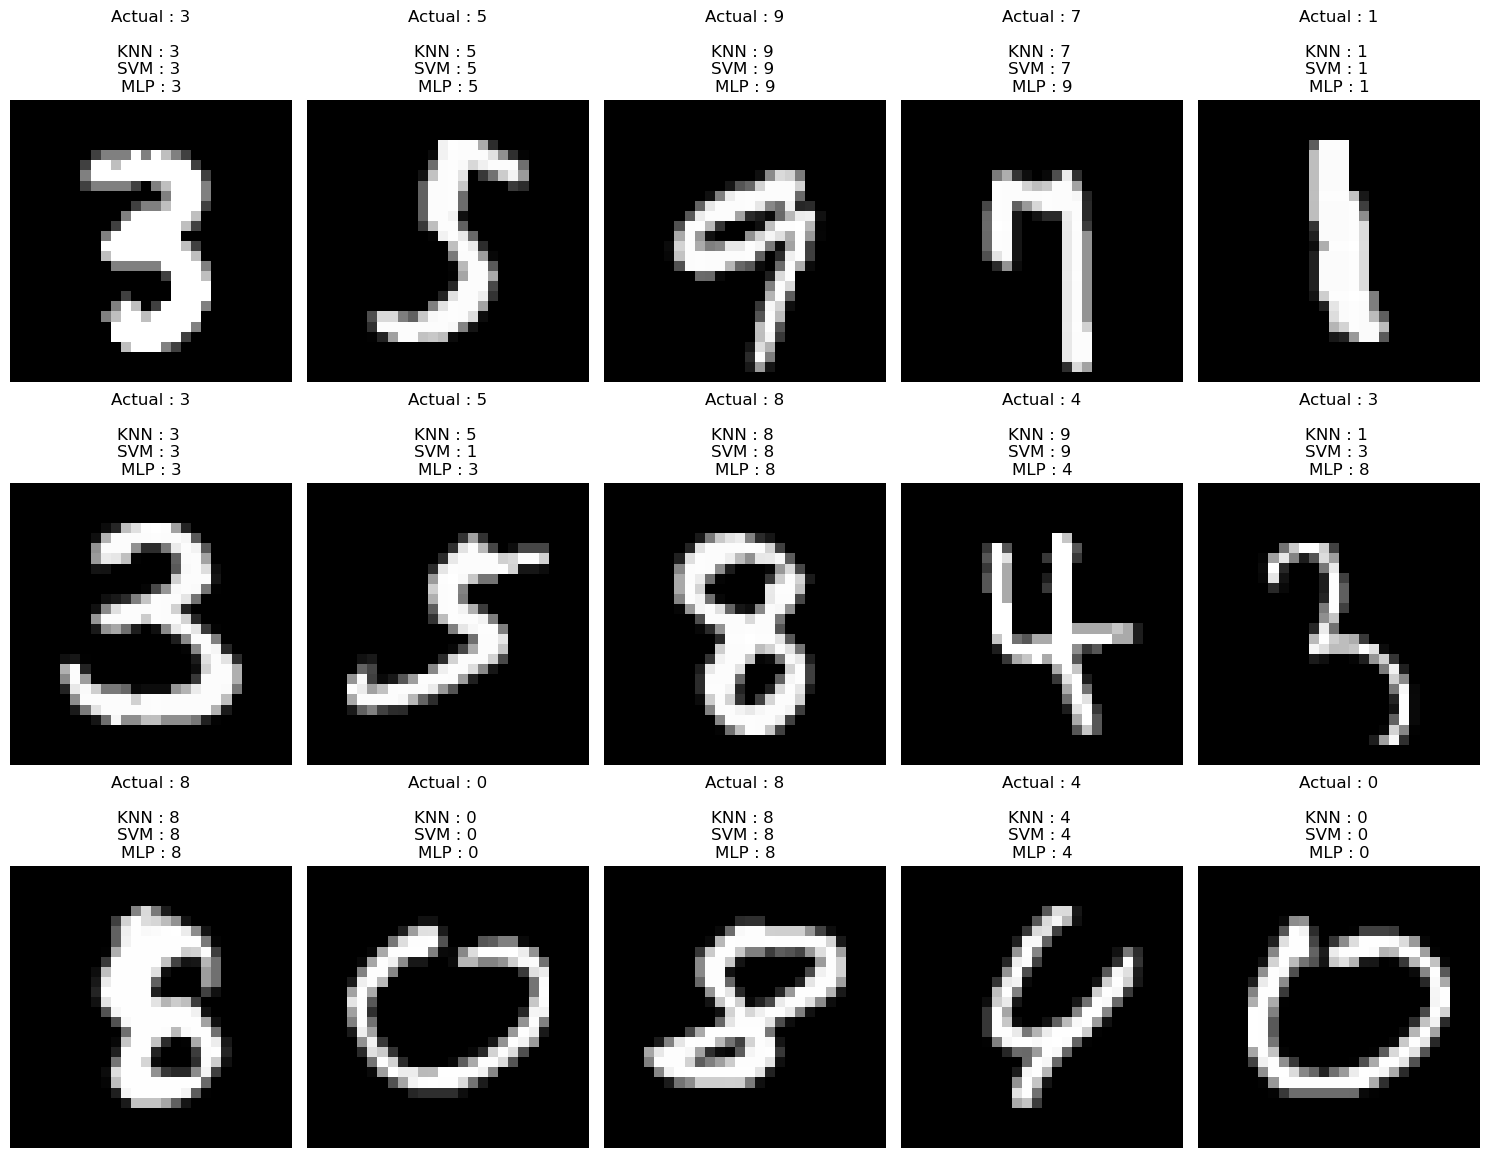

Actual Digit : 0
KNN Prediction : 0
SVM Prediction : 0
MLP Prediction : 0


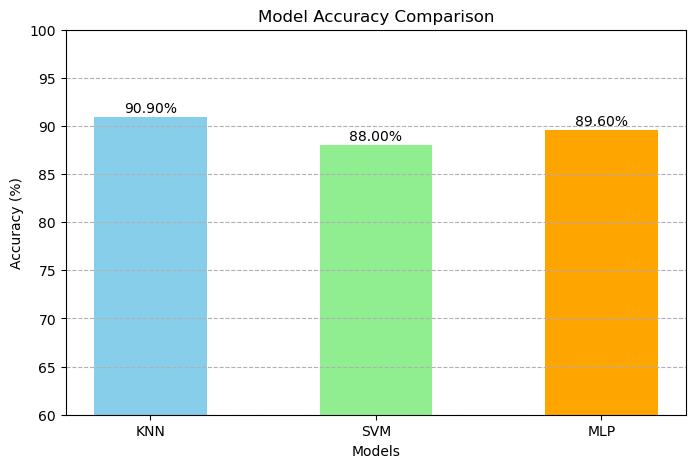


Displaying Confusion Matrices...


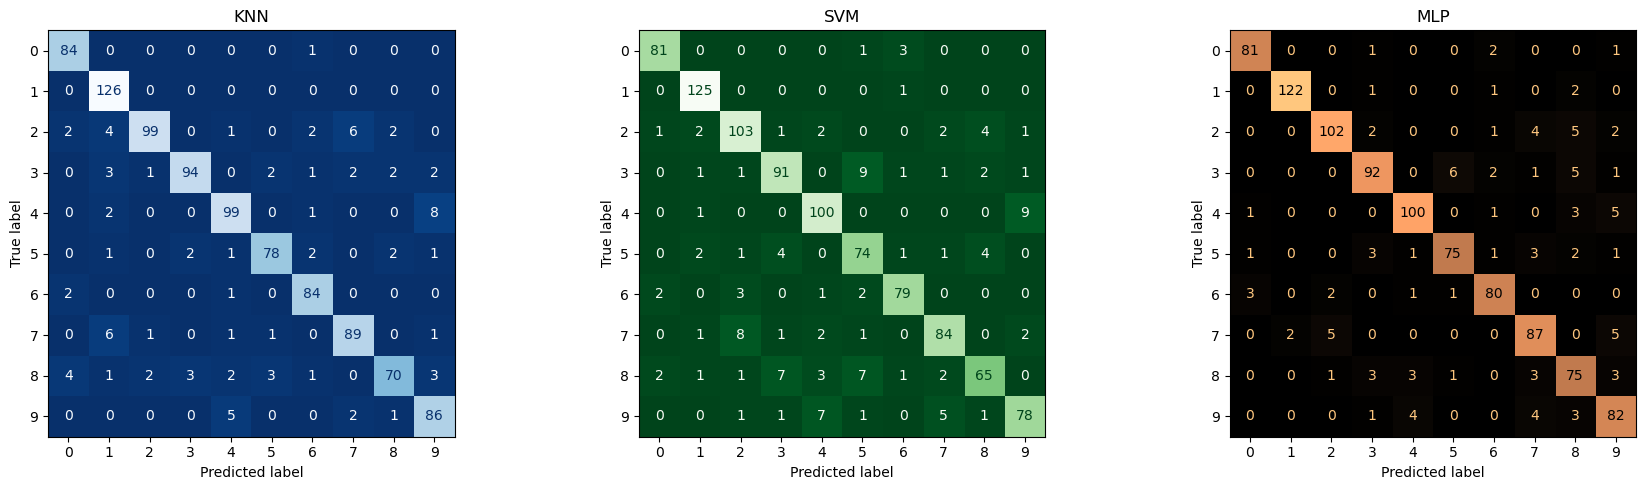


Project Executed Successfully!

Final Accuracies
KNN : 90.9 %
SVM : 88.0 %
MLP : 89.6 %

Best Performing Model : KNN


In [63]:
# Handwritten Digit Recognition Project
# Using KNN, SVM and ML

# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
# Load Dataset
print("Loading Dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print("Dataset Loaded Successfully!")

# Preprocessing
# Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten images for ML models
X_train_flat = X_train.reshape(len(X_train), 784)
X_test_flat = X_test.reshape(len(X_test), 784)

# KNN Model
print("\nTraining KNN Model...")
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_flat[:5000], y_train[:5000])
knn_pred = knn.predict(X_test_flat[:1000])
knn_accuracy = accuracy_score(
    y_test[:1000],
    knn_pred
)
print("KNN Accuracy :", knn_accuracy)

# SVM Model
print("\nTraining SVM Model...")
svm = SVC(kernel='linear')
svm.fit(X_train_flat[:3000], y_train[:3000])
svm_pred = svm.predict(X_test_flat[:1000])
svm_accuracy = accuracy_score(
    y_test[:1000],
    svm_pred
)
print("SVM Accuracy :", svm_accuracy)

# MLP Model
print("\nTraining MLP Model...")
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=10,
    random_state=42
)
mlp.fit(X_train_flat[:5000], y_train[:5000])
mlp_pred = mlp.predict(X_test_flat[:1000])
mlp_accuracy = accuracy_score(
    y_test[:1000],
    mlp_pred
)
print("MLP Accuracy :", mlp_accuracy)

## Random Image Prediction
"""index = np.random.choice(np.arange(len(X_train)), 24, replace=False)
igure, axes = plt.subplots(nrows=4, ncols=6, figsize=(16, 9))
for item in zip(axes.ravel(), X_train[index], y_train[index]): 
    axes, image, target = item 
    axes.imshow(image, cmap=plt.cm.gray_r) 
    axes.set_xticks([])   # remove x-axis tick marks 
    axes.set_yticks([])   
    axes.set_title(target) 
    plt.tight_layout() """
# MULTIPLE RANDOM IMAGE PREDICTIONS
print("\nDisplaying Multiple Predictions...")
plt.figure(figsize=(15,12))
for i in range(15):
    # Random index
    random_index = np.random.randint(0, 1000)
    # Image
    image = X_test[random_index]
    # Actual digit
    actual = y_test[random_index]
    # Predictions
    knn_output = knn.predict(
        [X_test_flat[random_index]]
    )[0]
    svm_output = svm.predict(
        [X_test_flat[random_index]]
    )[0]
    mlp_output = mlp.predict(
        [X_test_flat[random_index]]
    )[0]
    # Display image
    plt.subplot(3, 5, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(
        f"Actual : {actual}\n\n"
        f"KNN : {knn_output} \n"
        f"SVM : {svm_output} \n"
        f"MLP : {mlp_output}"
    )
    plt.axis('off')
plt.tight_layout()
plt.show()

# Print predictions
print("Actual Digit :", actual)
print("KNN Prediction :", knn_output)
print("SVM Prediction :", svm_output)
print("MLP Prediction :", mlp_output)

# Accuracy Comparison Graph
models = ['KNN', 'SVM', 'MLP']
accuracies = [
    knn_accuracy * 100,
    svm_accuracy * 100,
    mlp_accuracy * 100
]
plt.figure(figsize=(8,5))
bars = plt.bar(models, 
               accuracies,
               width=0.5,
               color=['skyblue', 'lightgreen', 'orange'])

# Add values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.5,
        f"{yval:.2f}%",
        ha='center'
    )
plt.ylim(60,100)
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.grid(axis='y', linestyle='--')
plt.show()

# CONFUSION MATRICES FOR ALL MODELS IN ONE ROW
print("\nDisplaying Confusion Matrices...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# KNN CONFUSION MATRIX
knn_cm = confusion_matrix(y_test[:1000], knn_pred)
ConfusionMatrixDisplay(knn_cm).plot(
    cmap='Blues_r',
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("KNN")

# SVM CONFUSION MATRIX
svm_cm = confusion_matrix(y_test[:1000], svm_pred)
ConfusionMatrixDisplay(svm_cm).plot(
    cmap='Greens_r',
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("SVM")

# MLP CONFUSION MATRIX
mlp_cm = confusion_matrix(y_test[:1000], mlp_pred)
ConfusionMatrixDisplay(mlp_cm).plot(
    cmap='copper',
    ax=axes[2],
    colorbar=False
)
axes[2].set_title("MLP")
plt.tight_layout()
plt.show()

# Final Summary
print("\nProject Executed Successfully!")
print("\nFinal Accuracies")
print("KNN :", round(knn_accuracy * 100, 2), "%")
print("SVM :", round(svm_accuracy * 100, 2), "%")
print("MLP :", round(mlp_accuracy * 100, 2), "%")

# Best model
accuracy_dict = {
    "KNN": knn_accuracy,
    "SVM": svm_accuracy,
    "MLP": mlp_accuracy
}
best_model = max(accuracy_dict,key=accuracy_dict.get)
print("\nBest Performing Model :", best_model)
